**I Made Ananta Wijaya**


**Analisis Risiko Kredit pada German Credit Dataset**


**Objective:**

Memprediksi probabilitas risiko kredit (baik/buruk) dari calon debitur menggunakan algoritma Logistic Regression, Decision Tree, Random Forest, Extra Tree berdasarkan fitur demografi, pekerjaan, dan riwayat perbankan.

# Deskripsi Data

| Variabel | Deskripsi |
| :--- | :--- |
| **Age (Usia)** | **Numeric**: Usia pemohon dalam tahun |
| **Sex (Jenis Kelamin)** | **Object**: Jenis kelamin pemohon (laki-laki, perempuan) |
| **Job (Pekerjaan)** | **Numeric**: Status pekerjaan (0: tidak terampil & bukan penduduk, 1: tidak terampil & penduduk menetap, 2: terampil, 3: sangat terampil) |
| **Housing (Tempat Tinggal)** | **Object**: Situasi tempat tinggal pemohon (milik sendiri, sewa, atau gratis/numpang) |
| **Saving accounts (Rekening tabungan)** | **Object**: Kekayaan dalam tabungan (sedikit, sedang, lumayan kaya, kaya) |
| **Checking account (Rekening giro)** | **Object**: Status rekening giro yang ada (dalam mata uang DM - Deutsch Mark) |
| **Credit amount (Jumlah kredit)** | **Numeric**: Jumlah kredit yang diajukan (dalam DM) |
| **Duration (Durasi)** | **Numeric**: Durasi kredit dalam hitungan bulan |
| **Purpose (Tujuan)** | **Object**: Tujuan pinjaman (mobil, furnitur/peralatan, radio/TV, peralatan rumah tangga, perbaikan, pendidikan, bisnis, liburan/lainnya) |
| **Risk (Risiko)** | **Object**: Evaluasi risiko kredit akhir (Variabel Target: baik atau buruk) |

# Import Library yang digunakan

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)
pd.set_option("display.max_columns", None)
sns.set_style('whitegrid')

In [65]:
df = pd.read_csv('/content/drive/MyDrive/Dibimbing Bootcamp/Assignment/Assignment Day 25/german_credit_data.csv')

In [66]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


# Data Understanding

In [67]:
# Menghapus kolom Unnamed
df = df.drop(columns='Unnamed: 0')

In [68]:
# Menampilkan informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [69]:
# Statistik deskriptif
df.describe(include='all')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


# Data Cleaning

In [70]:
print("Mengecek data yang duplikat:")
df.duplicated().sum()

Mengecek data yang duplikat:


np.int64(0)

In [71]:
print('Mengecek Missing Value:')
df.isnull().sum()

Mengecek Missing Value:


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [72]:
print('Mengecek Persentase missing value:')
(df.isnull().sum() / len(df)) * 100


Mengecek Persentase missing value:


,0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0
Risk,0.0


In [73]:
# Imputasi Missing value
for col in df[['Saving accounts', 'Checking account']]:
    df[col] = df[col].fillna('unknown')

df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,unknown,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,unknown,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


# Exploratory Data Analysis

# Univariate Analysis

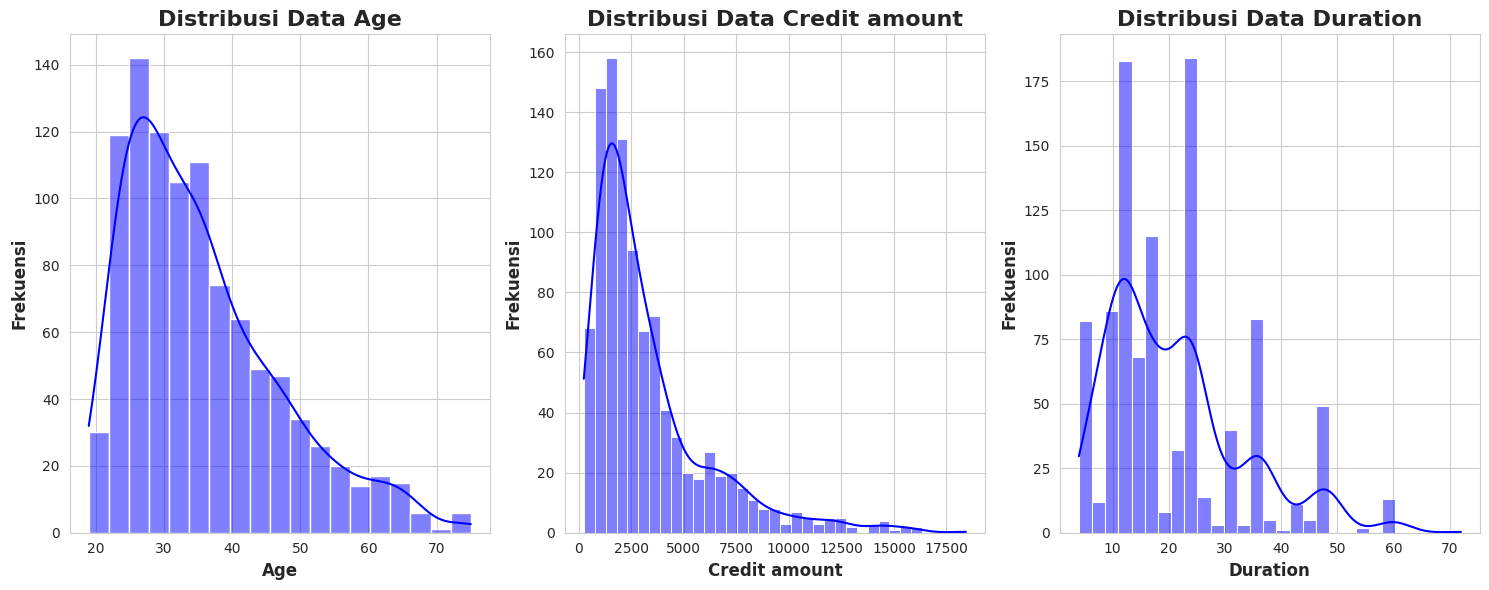

In [74]:
# Distribusi Data Kolom Numerik
numeric_col = ['Age', 'Credit amount', 'Duration']
plt.figure(figsize=(15, 6))
for i, kolom in enumerate(numeric_col):
  plt.subplot(1,3,i+1)
  sns.histplot(data=df, x=kolom, color='blue', kde=True)
  plt.title(f'Distribusi Data {kolom}', fontweight='bold',fontsize=16)
  plt.xlabel(kolom, fontweight='bold', fontsize=12)
  plt.ylabel('Frekuensi', fontweight='bold',fontsize=12)
plt.tight_layout()
plt.show()

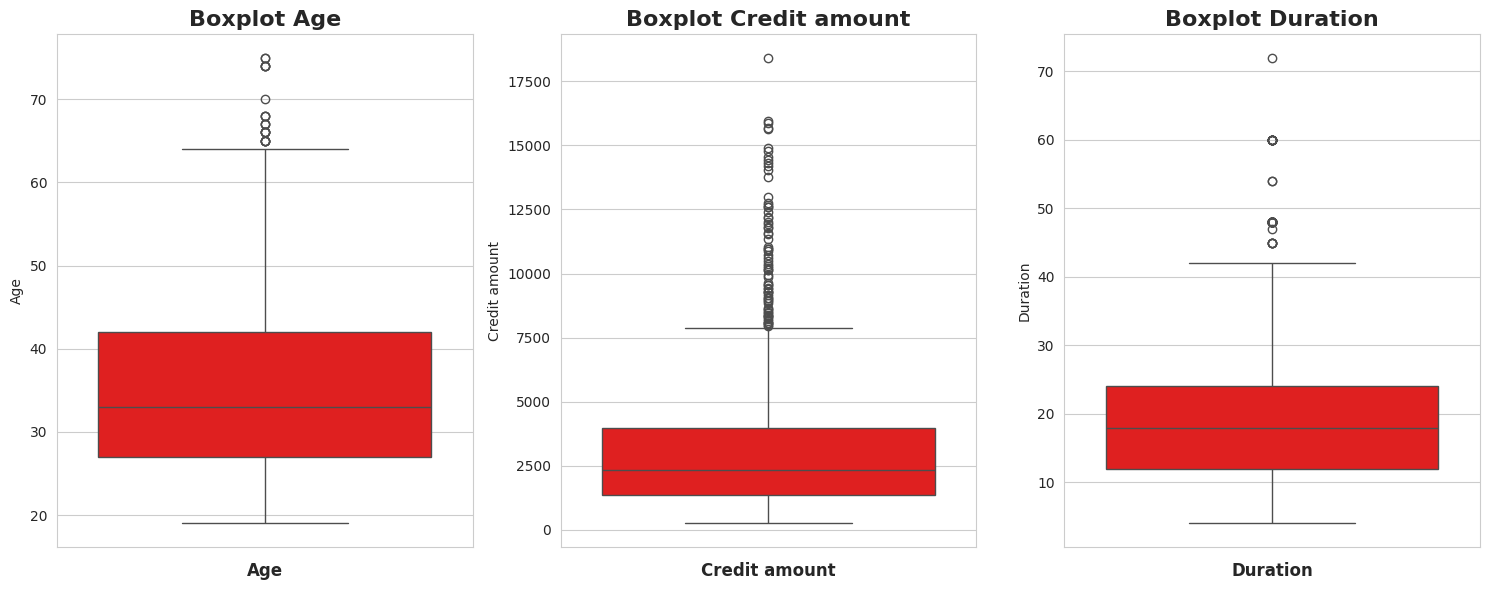

In [75]:
plt.figure(figsize=(15, 6))
for i, kolom in enumerate(numeric_col):
  plt.subplot(1,3,i+1)
  sns.boxplot(data=df, y=kolom, color='red')
  plt.title(f'Boxplot {kolom}', fontweight='bold',fontsize=16)
  plt.xlabel(kolom, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [76]:
# Mengecek durasi diatas atau sama dengan 60
df.query('Duration >=60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,unknown,10144,60,radio/TV,good
255,27,male,1,own,unknown,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,unknown,unknown,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,unknown,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,unknown,15653,60,radio/TV,good
672,42,male,3,own,little,unknown,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [77]:
# Membuat category colomns
cat_col = ['Sex',	'Job',	'Housing',	'Saving accounts',	'Checking account',	'Purpose']

## Apakah karakteristik demografis dan kondisi ekonomi calon debitur memiliki hubungan dengan risiko kredit?

/tmp/ipykernel_1847/3381868175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set1', order = df[col].value_counts().index)
/tmp/ipykernel_1847/3381868175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set1', order = df[col].value_counts().index)
/tmp/ipykernel_1847/3381868175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set1', order = df[col].value_counts().index)
/tmp/ipykernel_1847/3381868175.py:4: FutureWarning: 

Passing `palette` without as

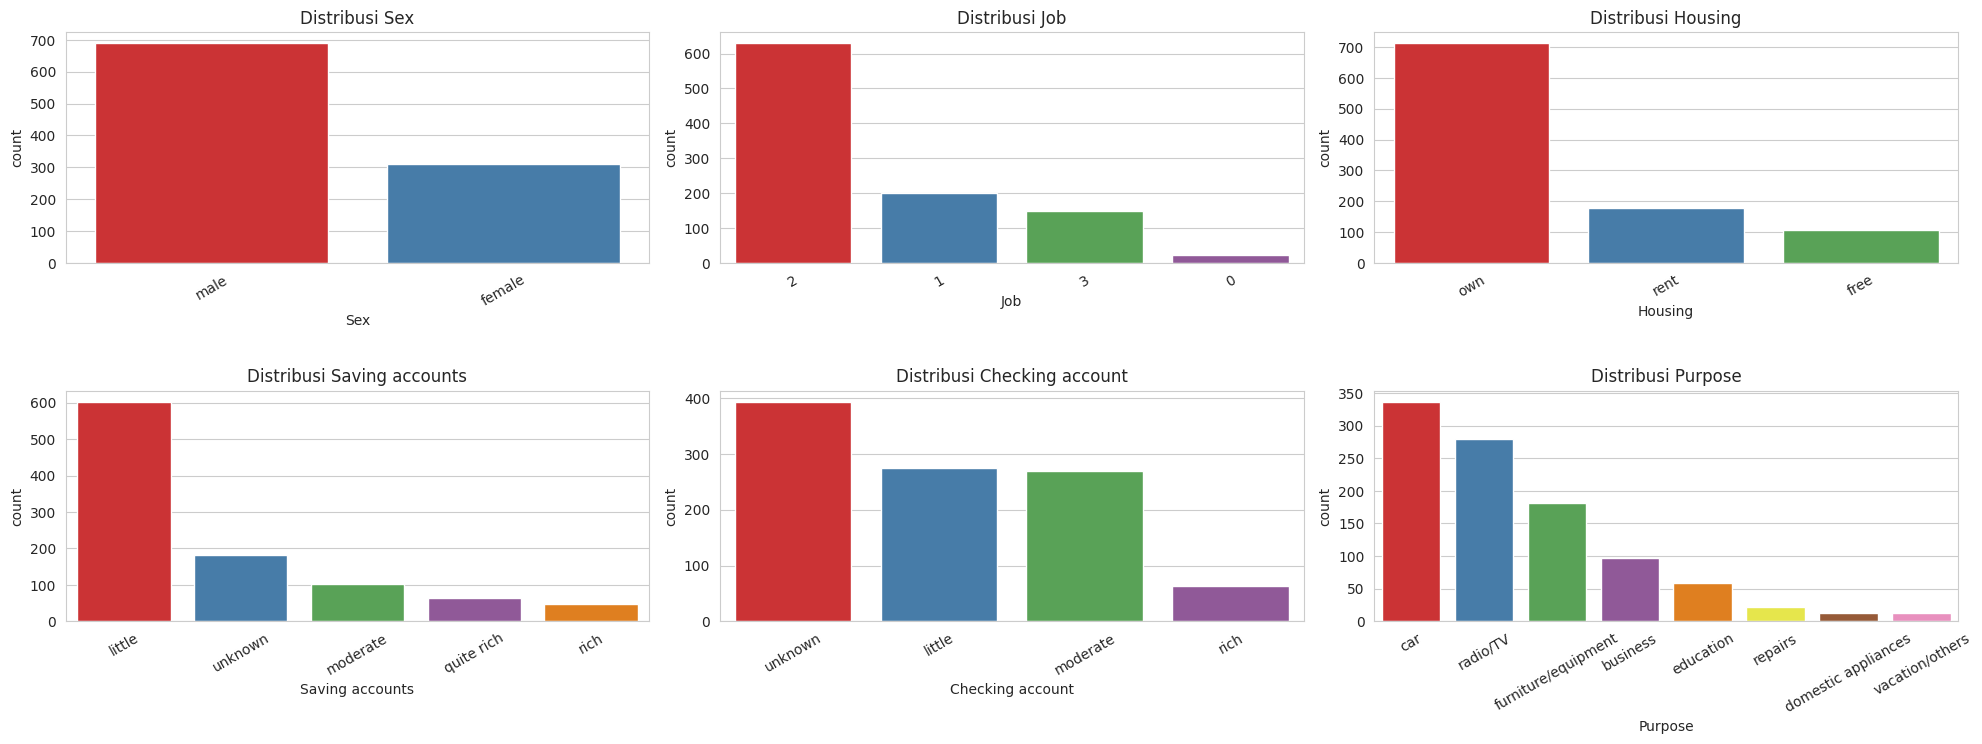

In [78]:
plt.figure(figsize=(20,10))
for i, col in enumerate(cat_col):
  plt.subplot(3,3, i+1)
  sns.countplot(data=df, x=col, palette='Set1', order = df[col].value_counts().index)
  plt.title(f'Distribusi {col}')
  plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

###Interpretasi

Berdasarkan perbandingan rata-rata berdasarkan Risk, debitur dengan kategori **bad** memiliki rata-rata **Credit amount** yang lebih tinggi dibandingkan debitur dengan kategori **good**, yaitu sekitar 3.938 dibandingkan 2.985. Selain itu, rata-rata **Duration** pada debitur dengan risiko bad juga lebih panjang, yaitu sekitar 24,86 dibandingkan 19,21.

Sementara itu, rata-rata **Age** pada debitur dengan risiko bad sedikit lebih rendah dibandingkan debitur dengan risiko good, yaitu sekitar 33,96 dibandingkan 36,22.

Hasil ini menunjukkan bahwa dalam dataset, debitur dengan risiko **bad cenderung memiliki jumlah kredit yang lebih besar dan durasi pinjaman yang lebih panjang**. Namun, hasil EDA ini menunjukkan adanya perbedaan/indikasi hubungan dan belum dapat digunakan untuk menyatakan bahwa variabel tersebut secara langsung menyebabkan risiko kredit menjadi bad.


# Bivatiate & Multivariate Analysis

In [79]:
cor = df[['Age','Credit amount', 'Duration']].corr()

In [80]:
cor

,Age,Credit amount,Duration
Age,1.000000,0.032716,-0.036136
Credit amount,0.032716,1.000000,0.624984
Duration,-0.036136,0.624984,1.000000


## Apakah terdapat hubungan antara usia, jumlah kredit, dan durasi pinjaman yang perlu diperhatikan dalam analisis risiko kredit?

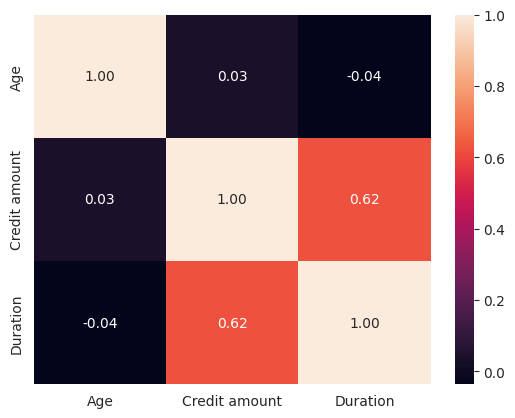

In [81]:
sns.heatmap(cor, annot=True, fmt='.2f')
plt.show()

### Interpretasi

Berdasarkan correlation matrix, hubungan antara **Age** dengan **Credit amount** sangat lemah dengan nilai korelasi sekitar **0,033**, sedangkan hubungan antara **Age** dengan **Duration** juga sangat lemah dengan nilai sekitar **-0,036**.

Sementara itu, **Credit amount** dan **Duration** memiliki korelasi positif sebesar **0,625**. Hal ini menunjukkan adanya hubungan positif yang cukup kuat, yaitu pinjaman dengan jumlah kredit yang lebih besar cenderung memiliki durasi pinjaman yang lebih panjang dalam dataset.

Dengan demikian, hubungan yang paling menonjol pada variabel numerik adalah hubungan antara **Credit amount dan Duration**.


In [82]:
df.groupby('Job')['Credit amount'].mean()

,Credit amount
Job,
0,2745.136364
1,2358.520000
2,3070.965079
3,5435.493243


In [83]:
df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [84]:
pd.pivot_table(df,
               values='Credit amount',
               index='Housing',
               columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


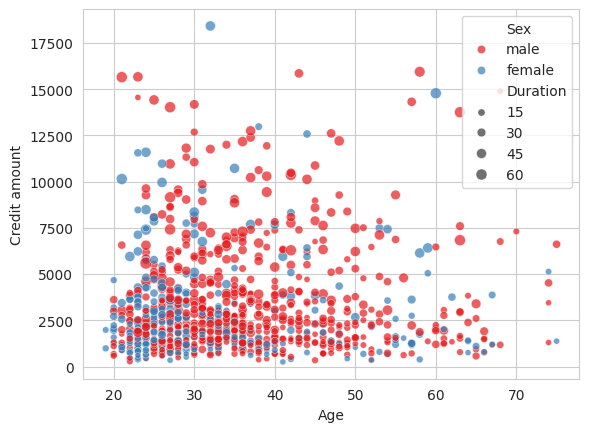

In [85]:
sns.scatterplot(data=df,
                x='Age',
                y = 'Credit amount',
                hue='Sex',
                size='Duration',
                alpha=0.7,
                palette='Set1')

plt.show()

/tmp/ipykernel_1847/1532201871.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,


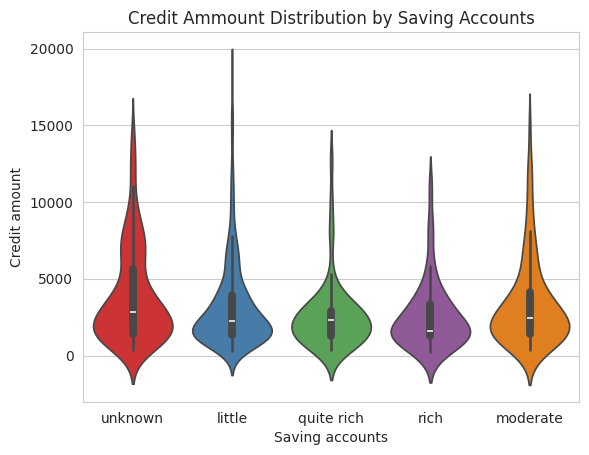

In [86]:
sns.violinplot(data=df,
               x='Saving accounts',
               y='Credit amount',
               palette='Set1')
plt.title('Credit Ammount Distribution by Saving Accounts')
plt.show()

In [87]:
df['Risk'].value_counts(normalize=True) * 100

,proportion
Risk,
good,70.0
bad,30.0


/tmp/ipykernel_1847/2247758260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Set1')
/tmp/ipykernel_1847/2247758260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Set1')
/tmp/ipykernel_1847/2247758260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Set1')


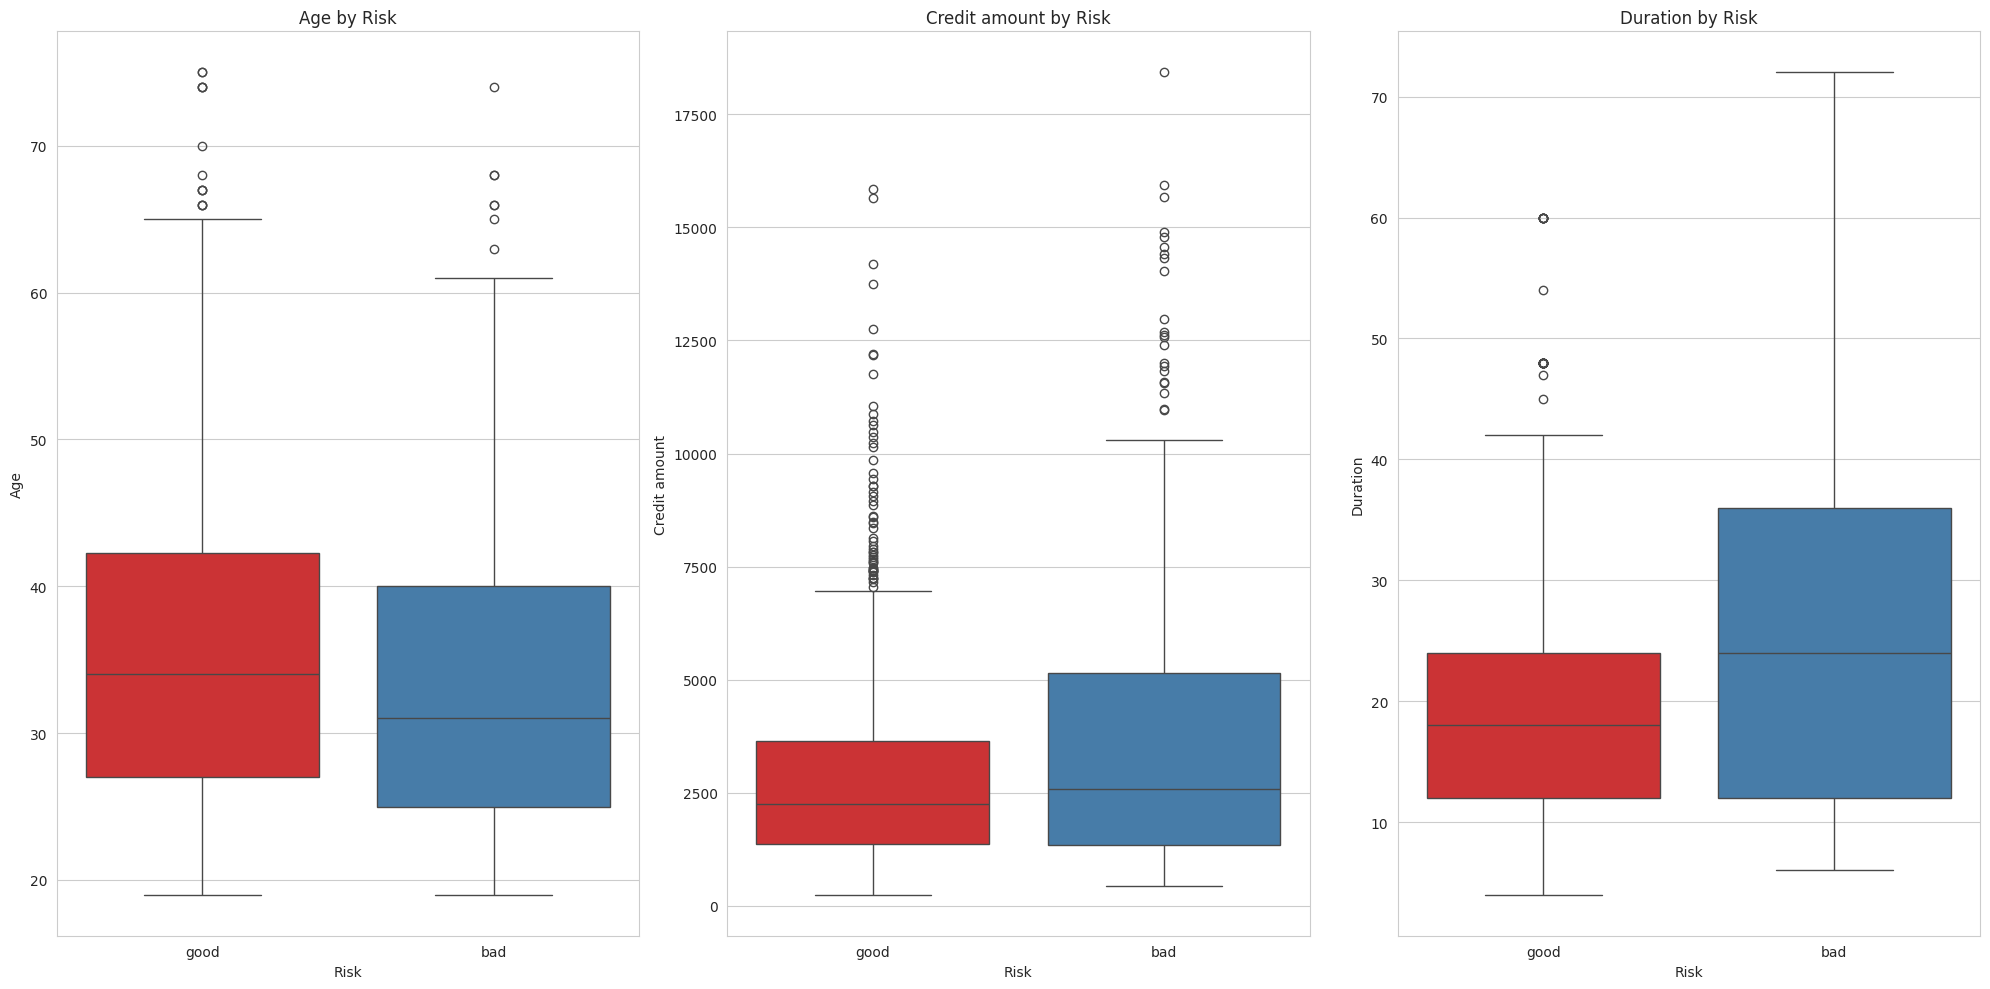

In [88]:
plt.figure(figsize=(20,10))
for i, col in enumerate(['Age','Credit amount', 'Duration']):
  plt.subplot(1,3,i+1)
  sns.boxplot(data=df, x='Risk', y=col, palette='Set1')
  plt.title(f'{col} by Risk')

plt.tight_layout()
plt.show()

## Apakah jumlah kredit dan durasi pinjaman cenderung berbeda antara debitur dengan risiko kredit baik dan buruk?

In [89]:
df.groupby('Risk')[['Age','Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


### Interpretasi
Berdasarkan perbandingan rata-rata, debitur dengan risiko **bad** memiliki rata-rata jumlah kredit sebesar **3.938,13 DM** dan durasi pinjaman sekitar **24,86 bulan**, sedangkan debitur dengan risiko **good** memiliki rata-rata jumlah kredit sebesar **2.985,46 DM** dan durasi pinjaman sekitar **19,21 bulan**. Hal ini menunjukkan bahwa dalam dataset, debitur dengan risiko bad cenderung memiliki **jumlah kredit yang lebih besar dan durasi pinjaman yang lebih panjang** dibandingkan debitur dengan risiko good. Rata-rata usia debitur bad juga sedikit lebih rendah, yaitu sekitar **33,96 tahun**, dibandingkan good sebesar **36,22 tahun**. Temuan ini menunjukkan adanya perbedaan karakteristik numerik antara kedua kelompok risiko, tetapi hasil EDA ini bersifat deskriptif dan tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat.


In [90]:
gcr_feature = ['Age','Sex','Job','Housing','Saving accounts','Checking account','Credit amount','Duration','Purpose']
gcr_target = ['Risk']

In [91]:
df_ml = df[gcr_feature + gcr_target].copy()

In [92]:
df_ml.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [93]:
cat_col = df_ml.select_dtypes(include='object').columns.drop('Risk')

In [94]:
df_ml['Risk'] = df_ml['Risk'].map({
    'good': 0,
    'bad': 1
})

In [95]:
df_ml.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,unknown,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


# Splitting Dataset

In [96]:
X = df_ml.drop(columns='Risk')

In [97]:
y = df_ml['Risk']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

In [99]:
X_train.shape

(700, 9)

In [100]:
X_test.shape

(300, 9)

# Preprocessing

In [101]:
numeric_features = [
    'Age',
    'Credit amount',
    'Duration'
]

In [102]:
categorical_features = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

In [103]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [104]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [105]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Logistic Regression

In [106]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

# Decision Tree

In [107]:
dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

# Random Forest

In [108]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Extra Tree

In [109]:
et = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Hyperparameter Grid

## Logistic Regression

In [110]:
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

## Decision Tree

In [111]:
dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

## Random Forest

In [112]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

## Extra Tree

In [113]:
et_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Train

In [114]:
def train_ml(model, param_grid, X_train, y_train):

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_

In [115]:
best_lr, params_lr = train_ml(
    lr,
    lr_param_grid,
    X_train,
    y_train
)

best_dt, params_dt = train_ml(
    dt,
    dt_param_grid,
    X_train,
    y_train
)

best_rf, params_rf = train_ml(
    rf,
    rf_param_grid,
    X_train,
    y_train
)

best_et, params_et = train_ml(
    et,
    et_param_grid,
    X_train,
    y_train
)

# Evaluation Model

In [116]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred

# 4 Model Evaluation

In [117]:
metrics_lr, pred_lr = evaluate_model(
    best_lr,
    X_test,
    y_test
)

metrics_dt, pred_dt = evaluate_model(
    best_dt,
    X_test,
    y_test
)

metrics_rf, pred_rf = evaluate_model(
    best_rf,
    X_test,
    y_test
)

metrics_et, pred_et = evaluate_model(
    best_et,
    X_test,
    y_test
)

# Model Comparation

In [118]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', **metrics_lr},
    {'Model': 'Decision Tree', **metrics_dt},
    {'Model': 'Random Forest', **metrics_rf},
    {'Model': 'Extra Trees', **metrics_et}
])

results.sort_values(
    by='F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.706667,0.507812,0.722222,0.596330,0.762011
0,Logistic Regression,0.696667,0.496241,0.733333,0.591928,0.768571
3,Extra Trees,0.673333,0.470588,0.711111,0.566372,0.754603
1,Decision Tree,0.610000,0.423729,0.833333,0.561798,0.681005


# ROC-AUC

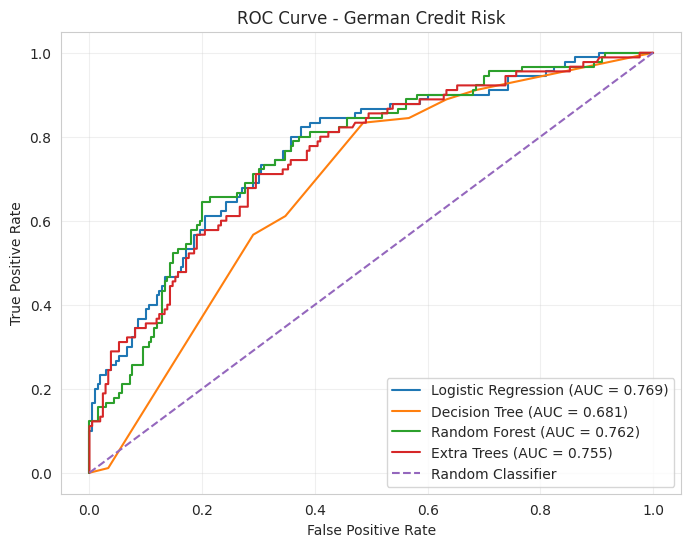

In [119]:
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_prob_et = best_et.predict_proba(X_test)[:, 1]

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_et, tpr_et, _ = roc_curve(y_test, y_prob_et)

# ROC-AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_et = roc_auc_score(y_test, y_prob_et)

# Visualisasi
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_et, tpr_et, label=f'Extra Trees (AUC = {auc_et:.3f})')

# Garis random classifier
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - German Credit Risk')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Classification Report

In [120]:
print(
    classification_report(
        y_test,
        pred_rf,
        target_names=['Good', 'Bad']
    )
)

              precision    recall  f1-score   support

        Good       0.85      0.70      0.77       210
         Bad       0.51      0.72      0.60        90

    accuracy                           0.71       300
   macro avg       0.68      0.71      0.68       300
weighted avg       0.75      0.71      0.72       300



# Confusion Matrix

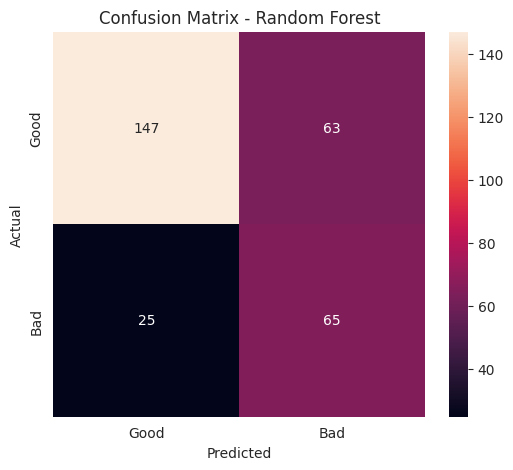

In [121]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Good', 'Bad'],
    yticklabels=['Good', 'Bad']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')

plt.show()

# Best Parameter

In [122]:
print("Logistic Regression:")
print(params_lr)

print("\nDecision Tree:")
print(params_dt)

print("\nRandom Forest:")
print(params_rf)

print("\nExtra Trees:")
print(params_et)

Logistic Regression:
{'model__C': 0.1, 'model__solver': 'liblinear'}

Decision Tree:
{'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}

Random Forest:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Extra Trees:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
